Modules

In [4]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt

<h1>Affichage du jeu de données</h1>

<h2> Analyse </h2>

In [5]:
path = "../RH_dataset.csv"

df = pd.read_csv(path, sep=";")

df.describe()

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,matricule,label
count,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000
mean,29.460739,7.934986,7.530322,11.632095,20.193947,41.767154,0.720711,1.554554,4168.404032,0.506853,1361.255858,0.031647
std,25.497874,7.549982,5.985476,9.218618,9.295469,11.014444,0.448659,0.657887,1657.829824,0.500299,794.183153,0.175062
min,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,1.000000,2134.000000,0.000000,0.000000,0.000000
25%,10.590000,3.180000,2.300000,3.800000,11.000000,34.000000,0.000000,1.000000,3197.000000,0.000000,655.000000,0.000000
50%,21.219999,5.880000,6.280000,9.870000,26.000000,41.000000,1.000000,1.000000,3629.000000,1.000000,1371.000000,0.000000
75%,41.400002,10.340000,11.070000,16.320000,28.000000,49.000000,1.000000,2.000000,4511.000000,1.000000,2072.000000,0.000000
max,152.970001,84.050003,33.119999,45.619999,36.000000,100.000000,1.000000,4.000000,18137.000000,2.000000,2675.000000,1.000000


In [10]:
#df.info()

#montre le nombre de matricules distincts
df["matricule"].value_counts(ascending=False)
df[df["matricule"] == 32]

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.91,0.97,27,30,1,1,3199,Marié(e),0,32,0
435,Production,11.280000,10.750000,1.18,1.20,27,30,1,1,3200,Marié(e),0,32,0
1735,Production,14.040000,13.590000,1.45,1.45,27,31,1,1,3200,Marié(e),0,32,0
3247,Production,16.920000,16.370001,1.70,1.70,27,32,1,1,3199,Marié(e),0,32,0
4799,Production,19.889999,19.340000,2.08,2.08,28,33,1,1,3199,Marié(e),0,32,0
6358,Etudes & Technique,2.350000,21.889999,2.27,2.38,27,34,1,1,3202,Marié(e),0,32,0
7967,Etudes & Technique,5.960000,0.960000,2.53,2.53,27,34,1,1,3560,Marié(e),0,32,0
9637,Etudes & Technique,8.710000,3.890000,2.77,2.77,27,34,1,1,3559,Marié(e),0,32,0
11353,Etudes & Technique,11.500000,6.770000,3.03,3.03,27,34,1,1,3560,Marié(e),0,32,0
13091,Etudes & Technique,14.770000,1.980000,3.25,3.31,27,35,1,1,3773,Marié(e),0,32,0


Affichage des valeurs nulles

In [6]:
df.isnull().sum()

Famille d'emploi                0
Dernière promotion (mois)       0
Dernière augmentation (mois)    0
Début de contrat (années)       0
Ancienneté groupe (années)      0
Etablissement                   0
Âge (années)                    0
Parent                          0
Niveau hiérarchique             0
Salaire (Euros)                 0
Statut marital                  0
Véhicule                        0
matricule                       0
label                           0
dtype: int64

Affichage de la matrice de corrélation

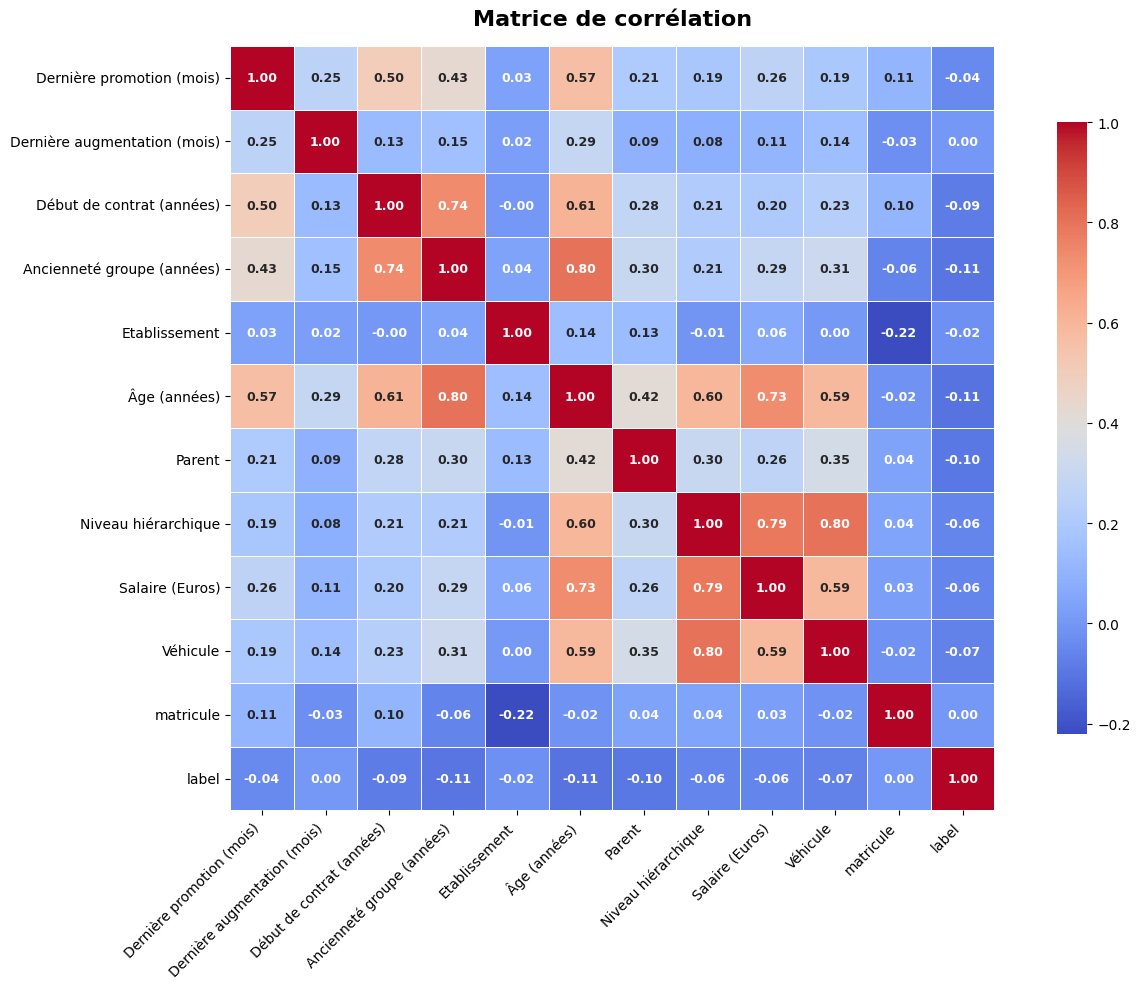

In [7]:
# Affichage de la matrice de corrélation en grandissant les valeurs numériques
num_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sb.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    square=True,
    annot_kws={"size": 9, "fontweight": "bold"},
    cbar_kws={"shrink": 0.8},
)
plt.title("Matrice de corrélation", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

On peut donc constater que les variables "âge" et "ancienneté" sont fortement corrélées, ce qui est logique. 
De même, les variables "salaire" et "âge"/"niveau hiérarchique" sont également corrélées, ce qui peut s'expliquer par le fait que les employés plus anciens ont généralement des salaires plus élevés.

Détection des outliers

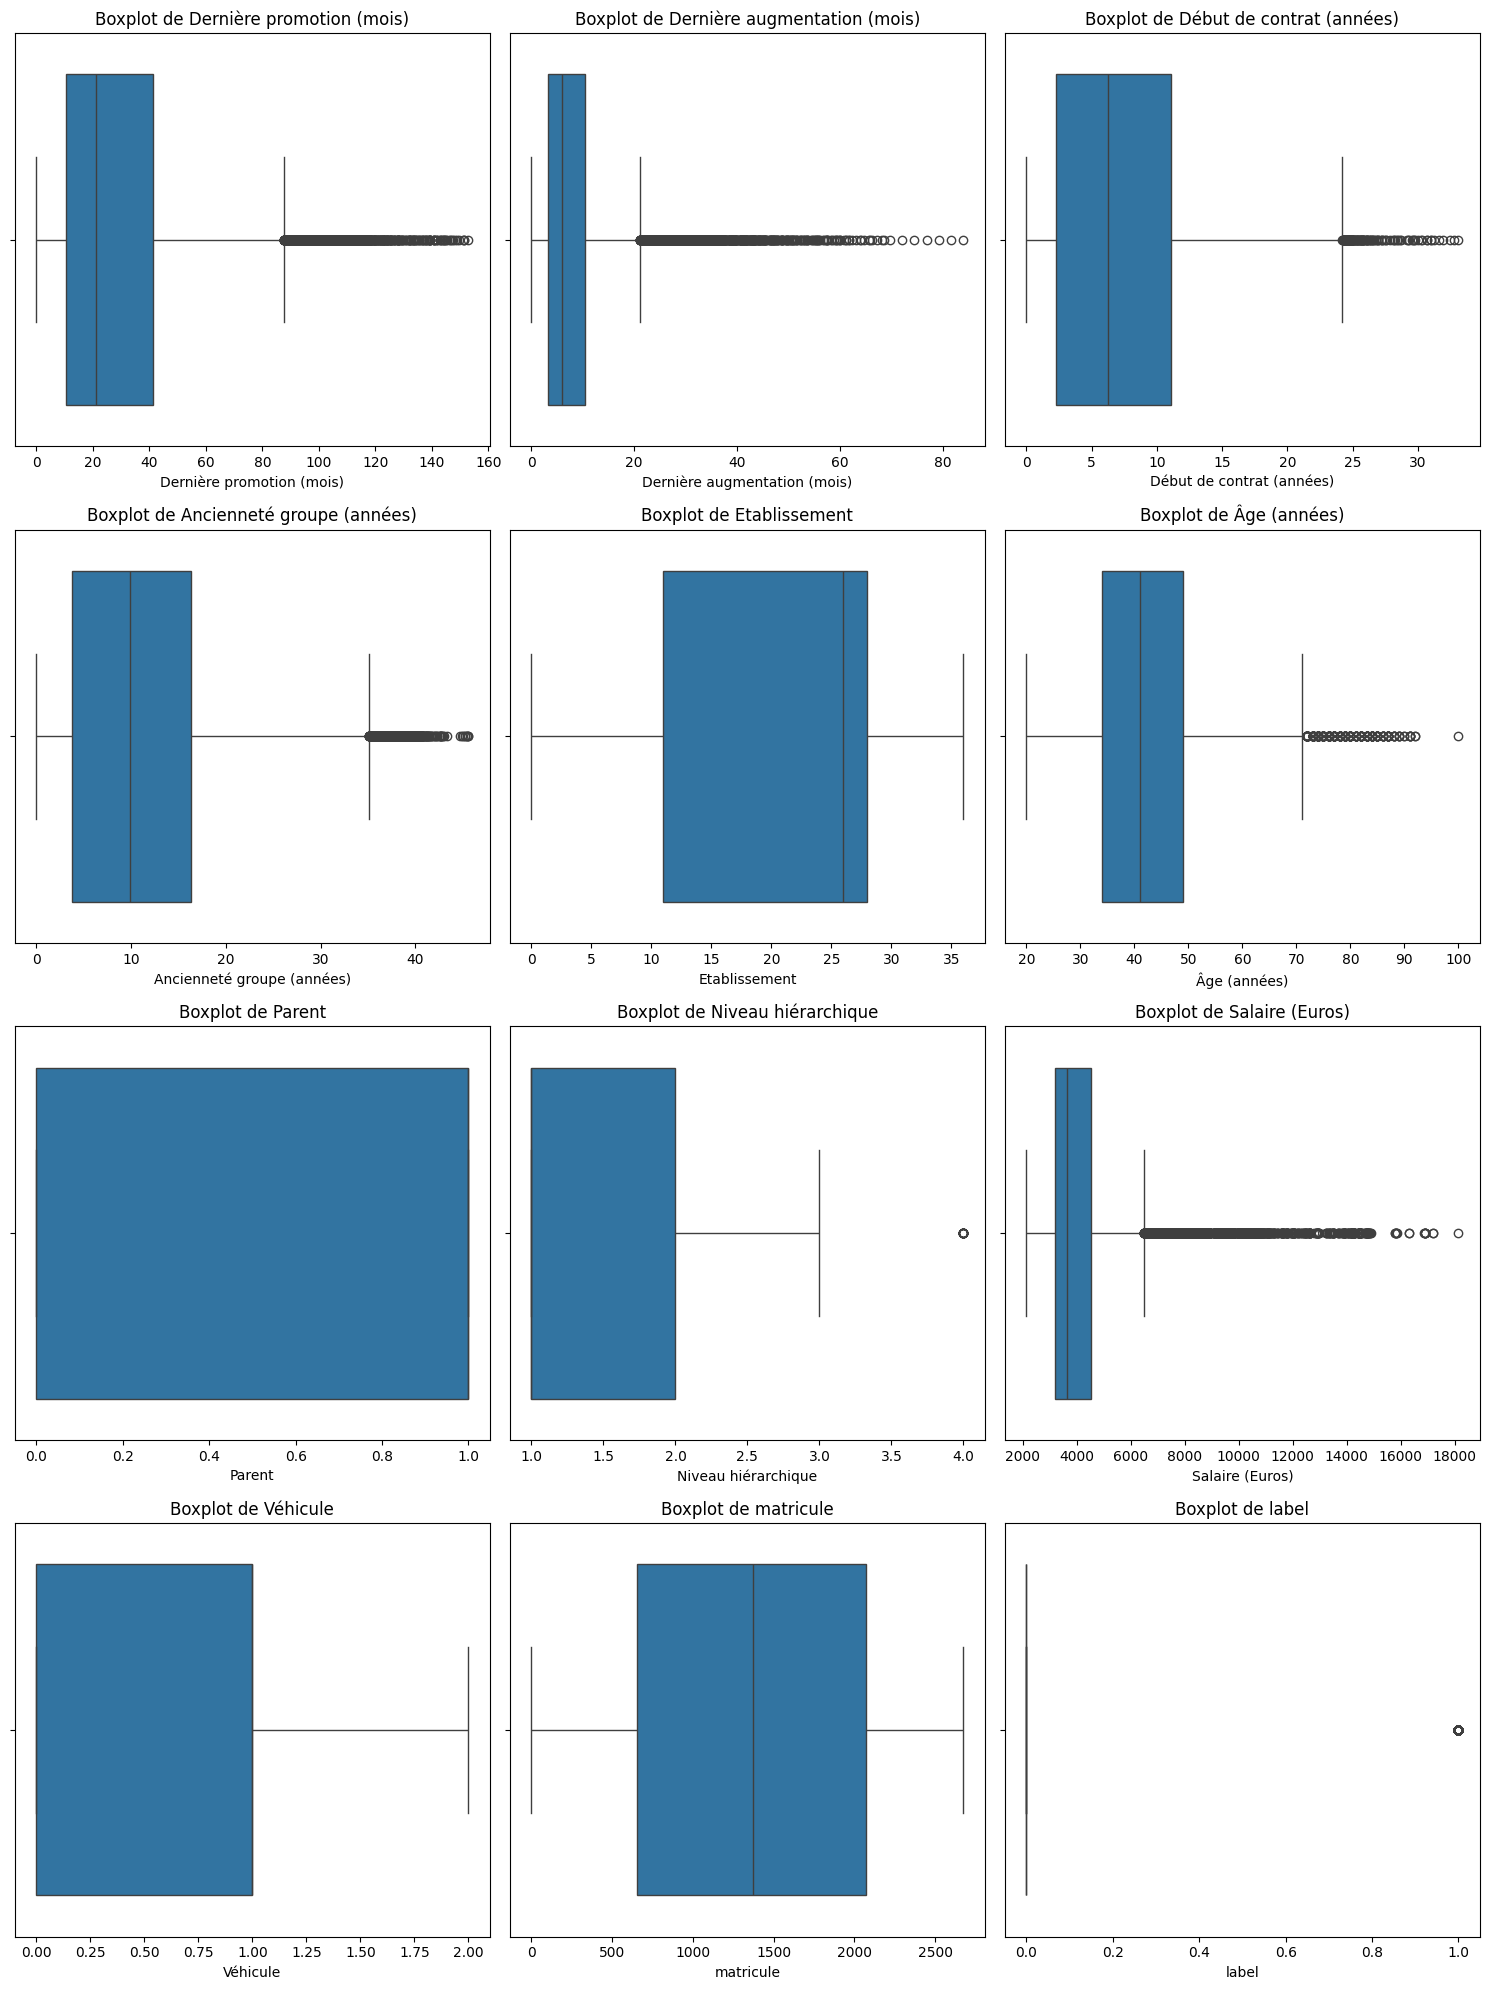

In [8]:
def outliers_displaying(df):

    num_cols = df.select_dtypes(include=np.number).columns
    num_plots = len(num_cols)
    cols = 3  # Nombre de colonnes dans la grille
    rows = (num_plots + cols - 1) // cols  # Calcul du nombre de lignes nécessaires     
    plt.figure(figsize=(15, 5 * rows))  # Ajustement de la taille de la figure
    for i, col in enumerate(num_cols):
        plt.subplot(rows, cols, i + 1)  # Positionnement du subplot
        sb.boxplot(x=df[col])
        plt.title(f"Boxplot de {col}")
    plt.tight_layout()  # Ajustement de l'espacement entre les subplots
    plt.show()

outliers_displaying(df)

Affichage des distributions des variables numériques

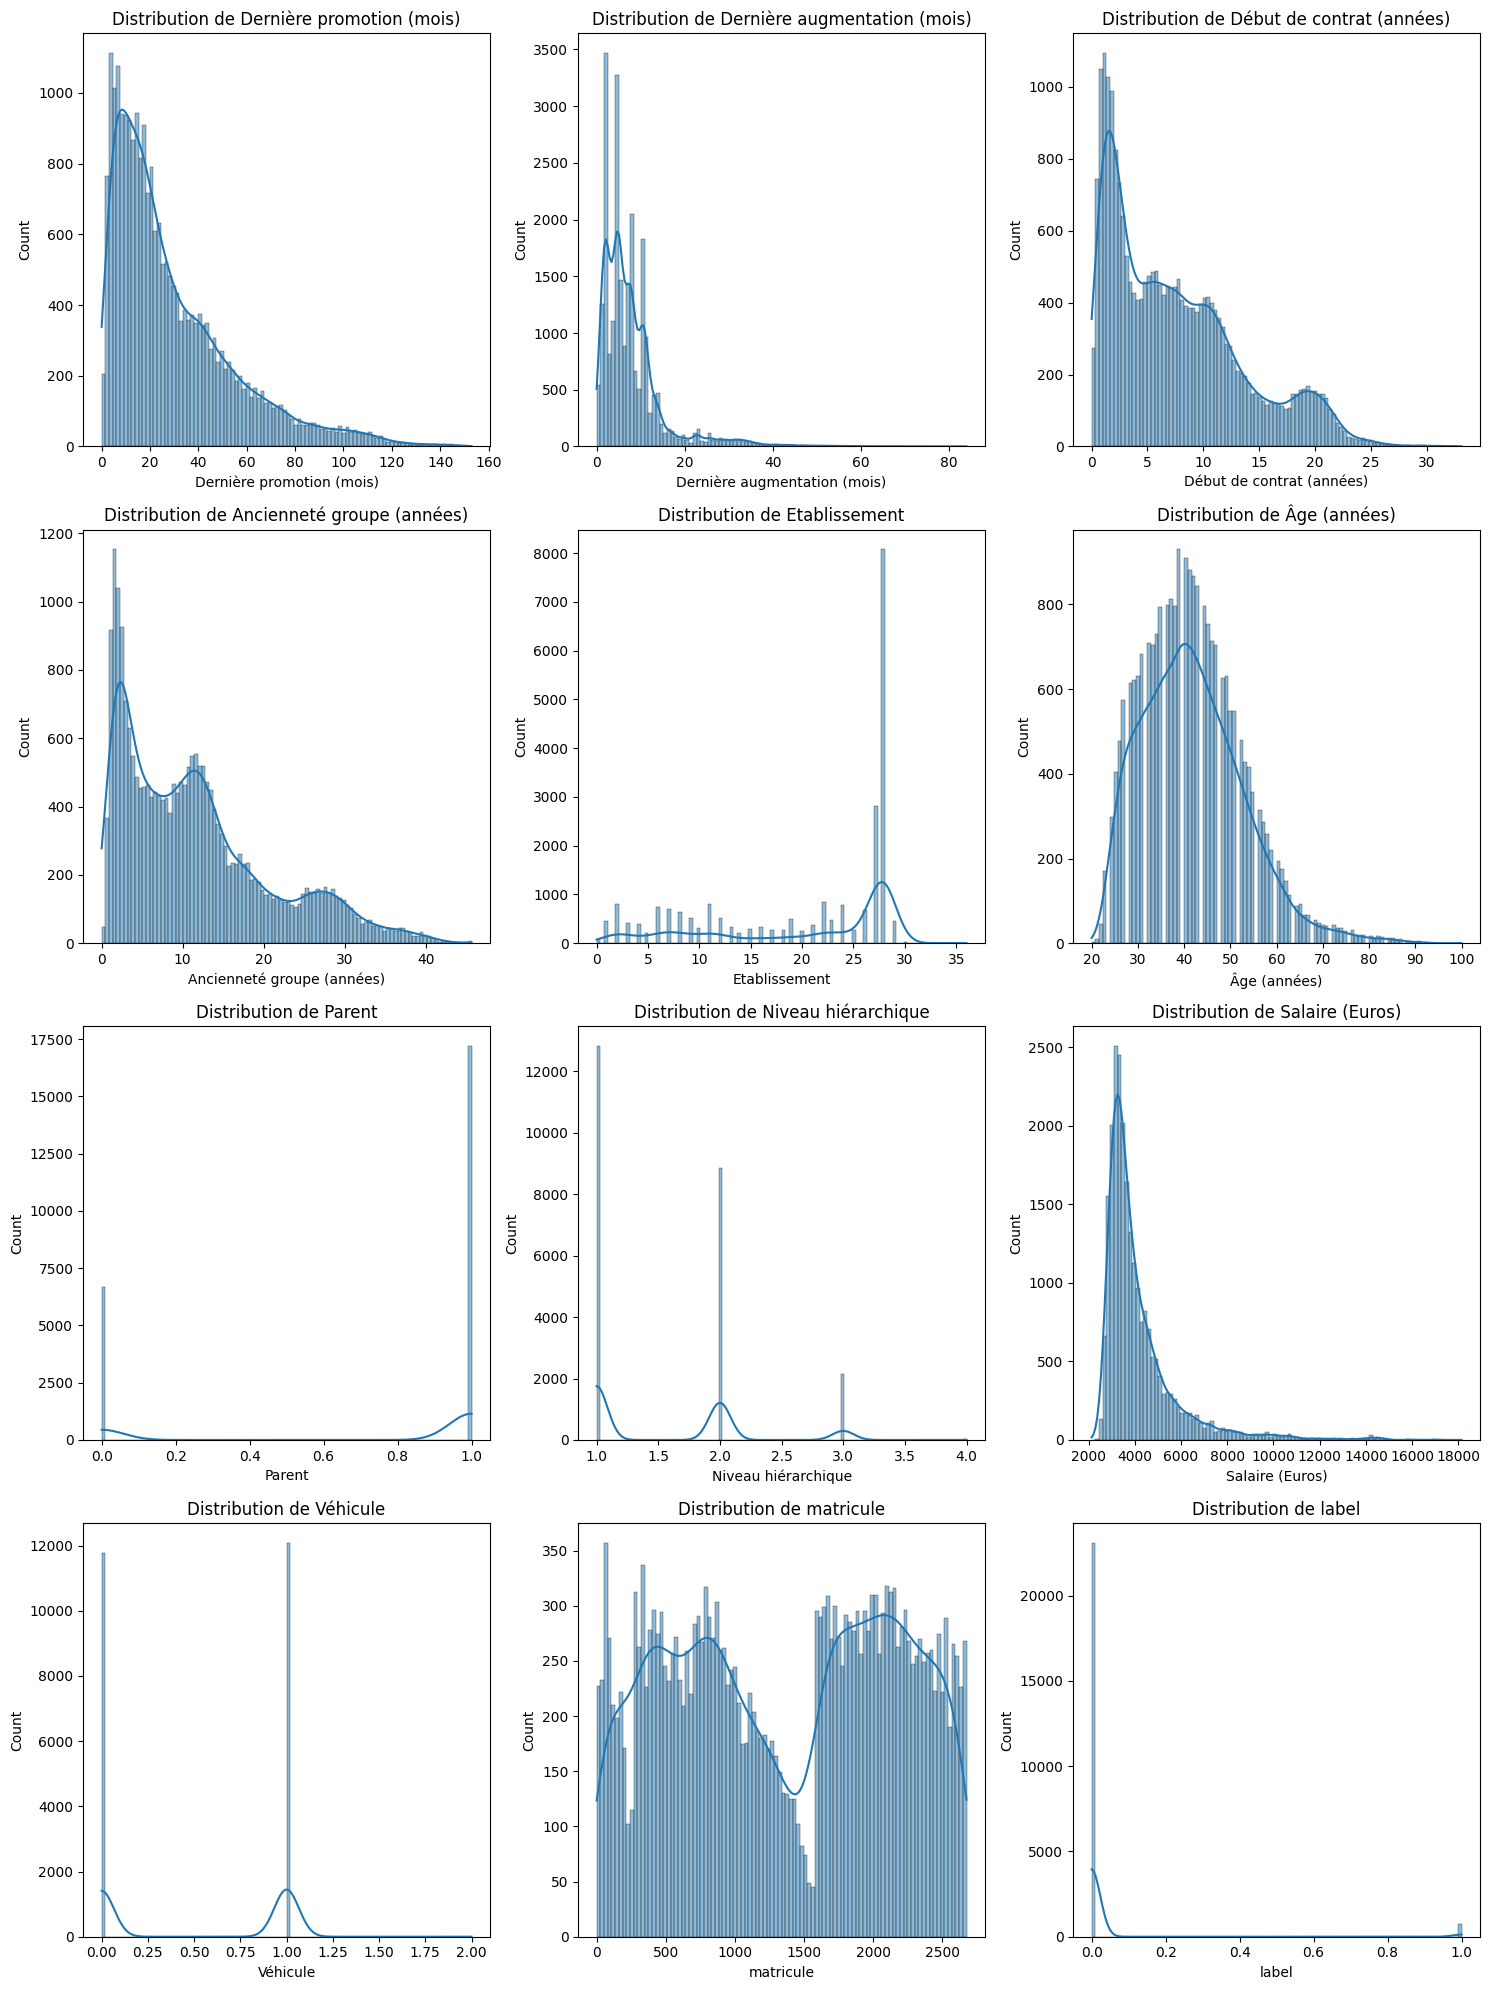

In [9]:
def distribution_displaying(df):
    num_cols = df.select_dtypes(include=np.number).columns
    num_plots = len(num_cols)
    cols = 3  # Nombre de colonnes dans la grille
    rows = (num_plots + cols - 1) // cols  # Calcul du nombre de lignes nécessaires     
    plt.figure(figsize=(15, 5 * rows))  # Ajustement de la taille de la figure
    for i, col in enumerate(num_cols):
        plt.subplot(rows, cols, i + 1)  # Positionnement du subplot
        sb.histplot(df[col], kde=True, bins=100)
        plt.title(f"Distribution de {col}")
    plt.tight_layout()  # Ajustement de l'espacement entre les subplots
    plt.show()

distribution_displaying(df)

<h2> Exhibition du parcours d'un employé qui a démissionné et celui d'un employé qui n'a pas démissionné </h2>

In [10]:
df_demission = df[df["label"] == 1]
df_non_demission = df[df["label"] == 0]

df_demission.info()

df_demission.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 755 entries, 3 to 23843
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              755 non-null    object 
 1   Dernière promotion (mois)     755 non-null    float64
 2   Dernière augmentation (mois)  755 non-null    float64
 3   Début de contrat (années)     755 non-null    float64
 4   Ancienneté groupe (années)    755 non-null    float64
 5   Etablissement                 755 non-null    int64  
 6   Âge (années)                  755 non-null    int64  
 7   Parent                        755 non-null    int64  
 8   Niveau hiérarchique           755 non-null    int64  
 9   Salaire (Euros)               755 non-null    int64  
 10  Statut marital                755 non-null    object 
 11  Véhicule                      755 non-null    int64  
 12  matricule                     755 non-null    int64  
 13  label   

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,matricule,label
count,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.0
mean,23.845894,8.060728,4.673563,6.245868,18.950993,35.270199,0.484768,1.344371,3635.705960,0.324503,1365.797351,1.0
std,17.400095,6.594335,4.034534,5.097133,9.963939,7.657011,0.500099,0.535805,1035.558766,0.468499,831.314521,0.0
min,0.280000,0.000000,0.100000,0.000000,0.000000,22.000000,0.000000,1.000000,2561.000000,0.000000,1.000000,1.0
25%,11.460000,3.895000,1.770000,2.360000,8.000000,29.000000,0.000000,1.000000,3001.000000,0.000000,634.500000,1.0
50%,19.350000,6.890000,3.200000,4.480000,25.000000,34.000000,0.000000,1.000000,3338.000000,0.000000,1232.000000,1.0
75%,31.179999,10.510000,6.315000,9.075000,28.000000,40.000000,1.000000,2.000000,3915.000000,1.000000,2199.000000,1.0
max,99.680000,41.709999,21.590000,28.070000,29.000000,65.000000,1.000000,3.000000,10927.000000,1.000000,2666.000000,1.0


In [11]:
df_non_demission.info()

df_non_demission.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 23102 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23102 non-null  object 
 1   Dernière promotion (mois)     23102 non-null  float64
 2   Dernière augmentation (mois)  23102 non-null  float64
 3   Début de contrat (années)     23102 non-null  float64
 4   Ancienneté groupe (années)    23102 non-null  float64
 5   Etablissement                 23102 non-null  int64  
 6   Âge (années)                  23102 non-null  int64  
 7   Parent                        23102 non-null  int64  
 8   Niveau hiérarchique           23102 non-null  int64  
 9   Salaire (Euros)               23102 non-null  int64  
 10  Statut marital                23102 non-null  object 
 11  Véhicule                      23102 non-null  int64  
 12  matricule                     23102 non-null  int64  
 13  label 

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,matricule,label
count,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.0
mean,29.644239,7.930876,7.623685,11.808123,20.234568,41.979482,0.728422,1.561423,4185.813220,0.512813,1361.107437,0.0
std,25.699102,7.579271,6.015819,9.270018,9.270229,11.042857,0.444783,0.660378,1671.420167,0.500193,792.958687,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,1.000000,2134.000000,0.000000,0.000000,0.0
25%,10.550000,3.142500,2.330000,3.920000,11.000000,34.000000,0.000000,1.000000,3203.000000,0.000000,658.000000,0.0
50%,21.299999,5.850000,6.430000,10.080000,26.000000,41.000000,1.000000,1.000000,3640.500000,1.000000,1379.500000,0.0
75%,41.689999,10.330000,11.190000,16.607501,28.000000,49.000000,1.000000,2.000000,4536.750000,1.000000,2068.000000,0.0
max,152.970001,84.050003,33.119999,45.619999,36.000000,100.000000,1.000000,4.000000,18137.000000,2.000000,2675.000000,0.0


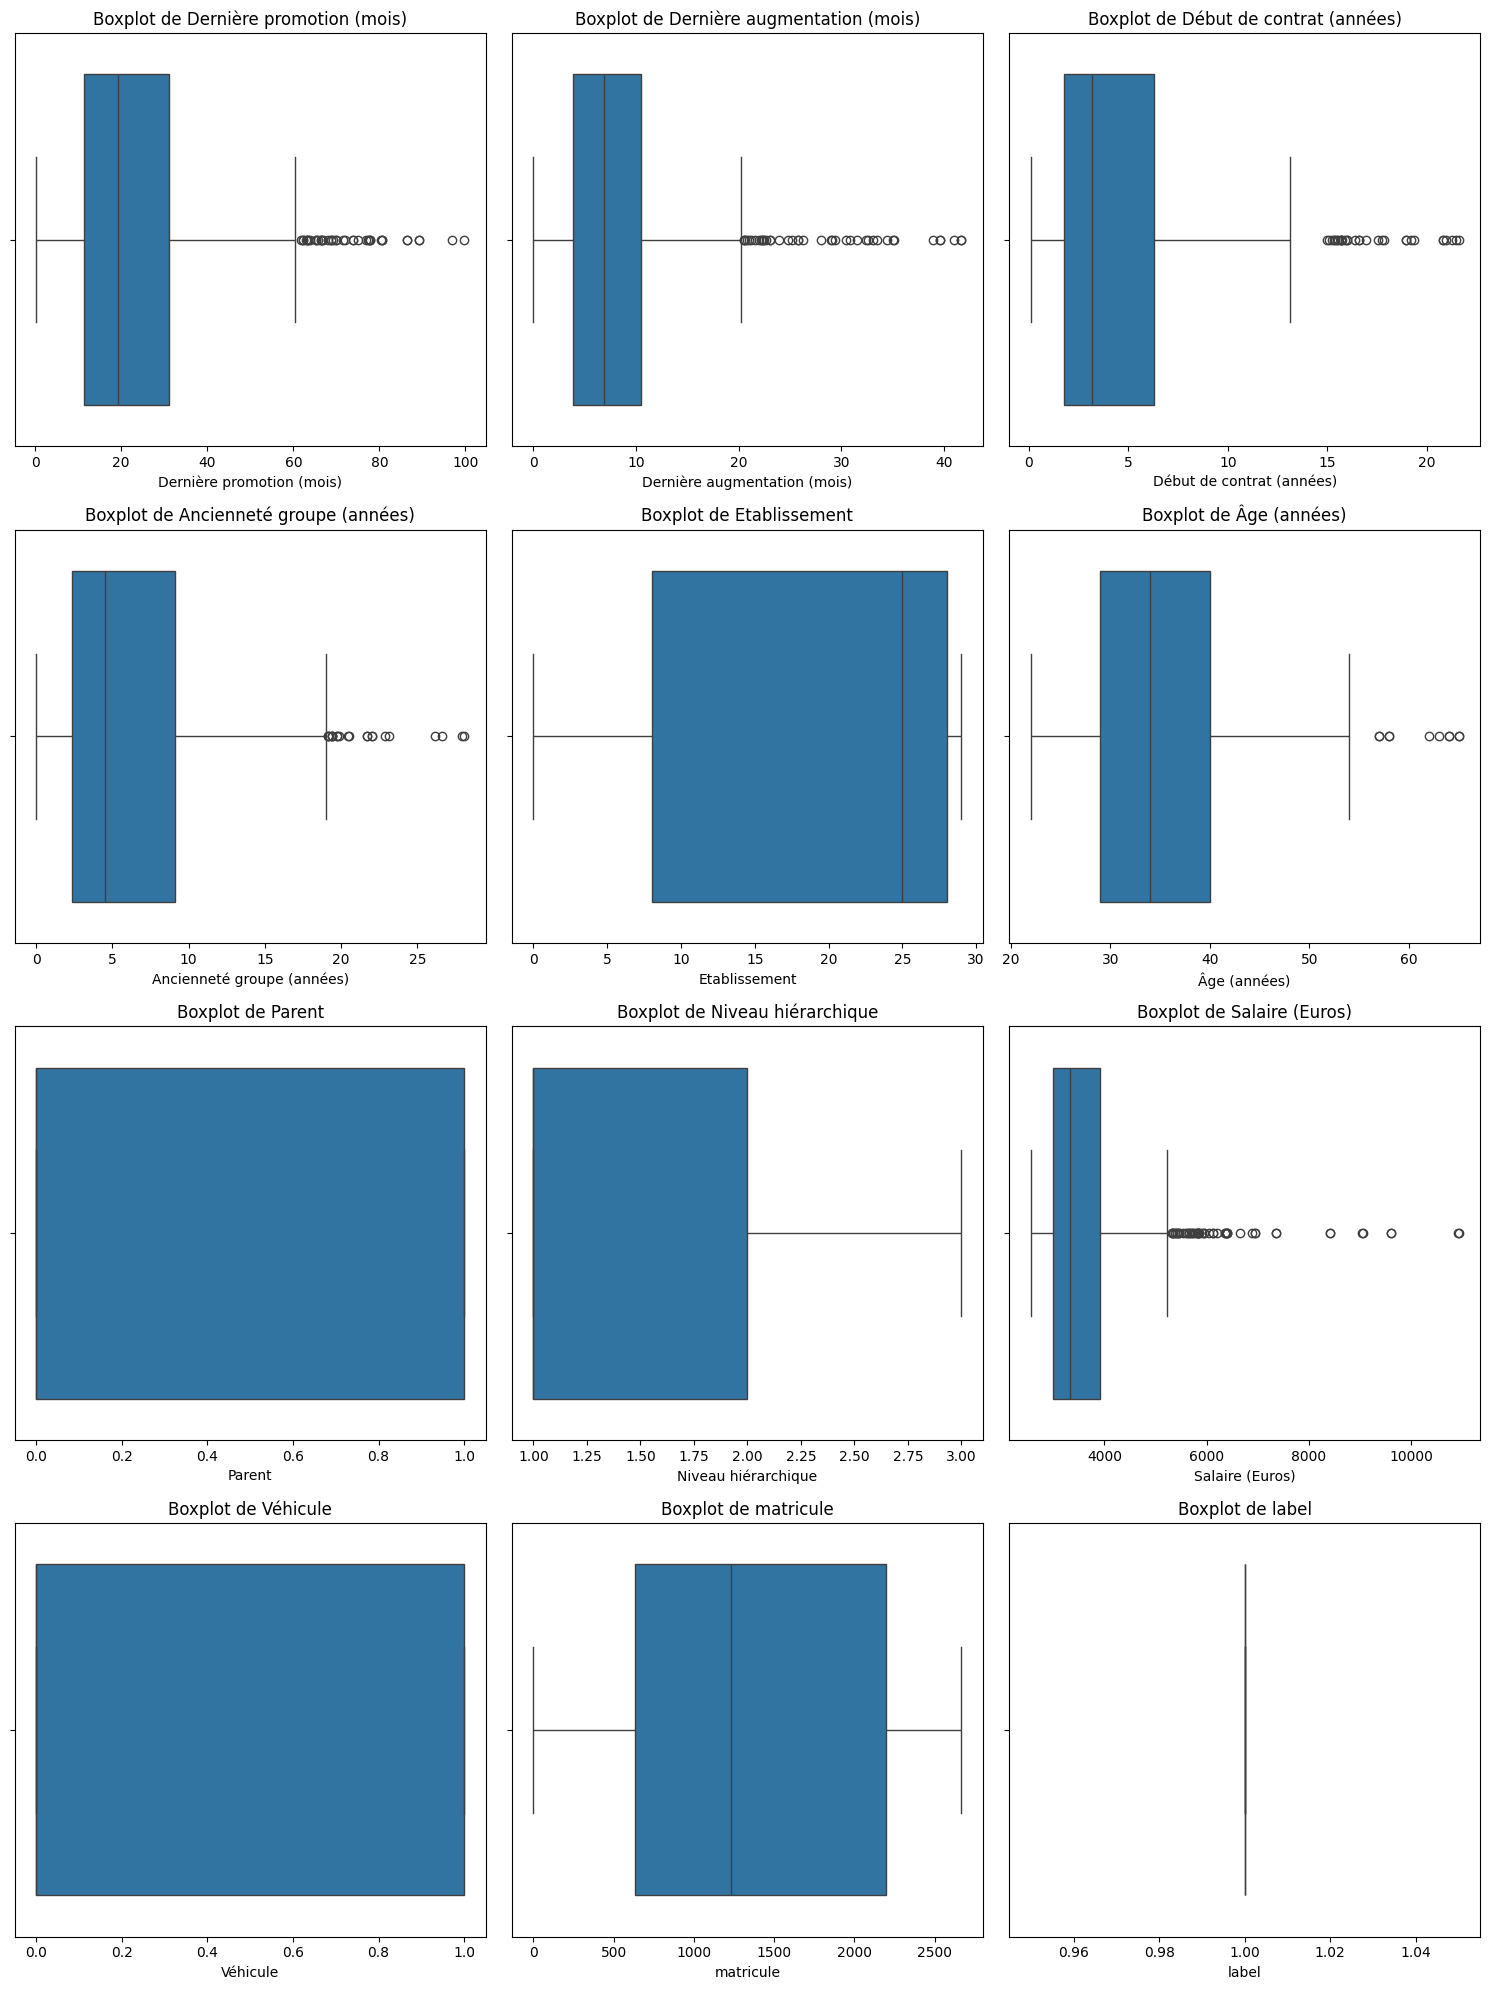

In [12]:
outliers_displaying(df_demission)

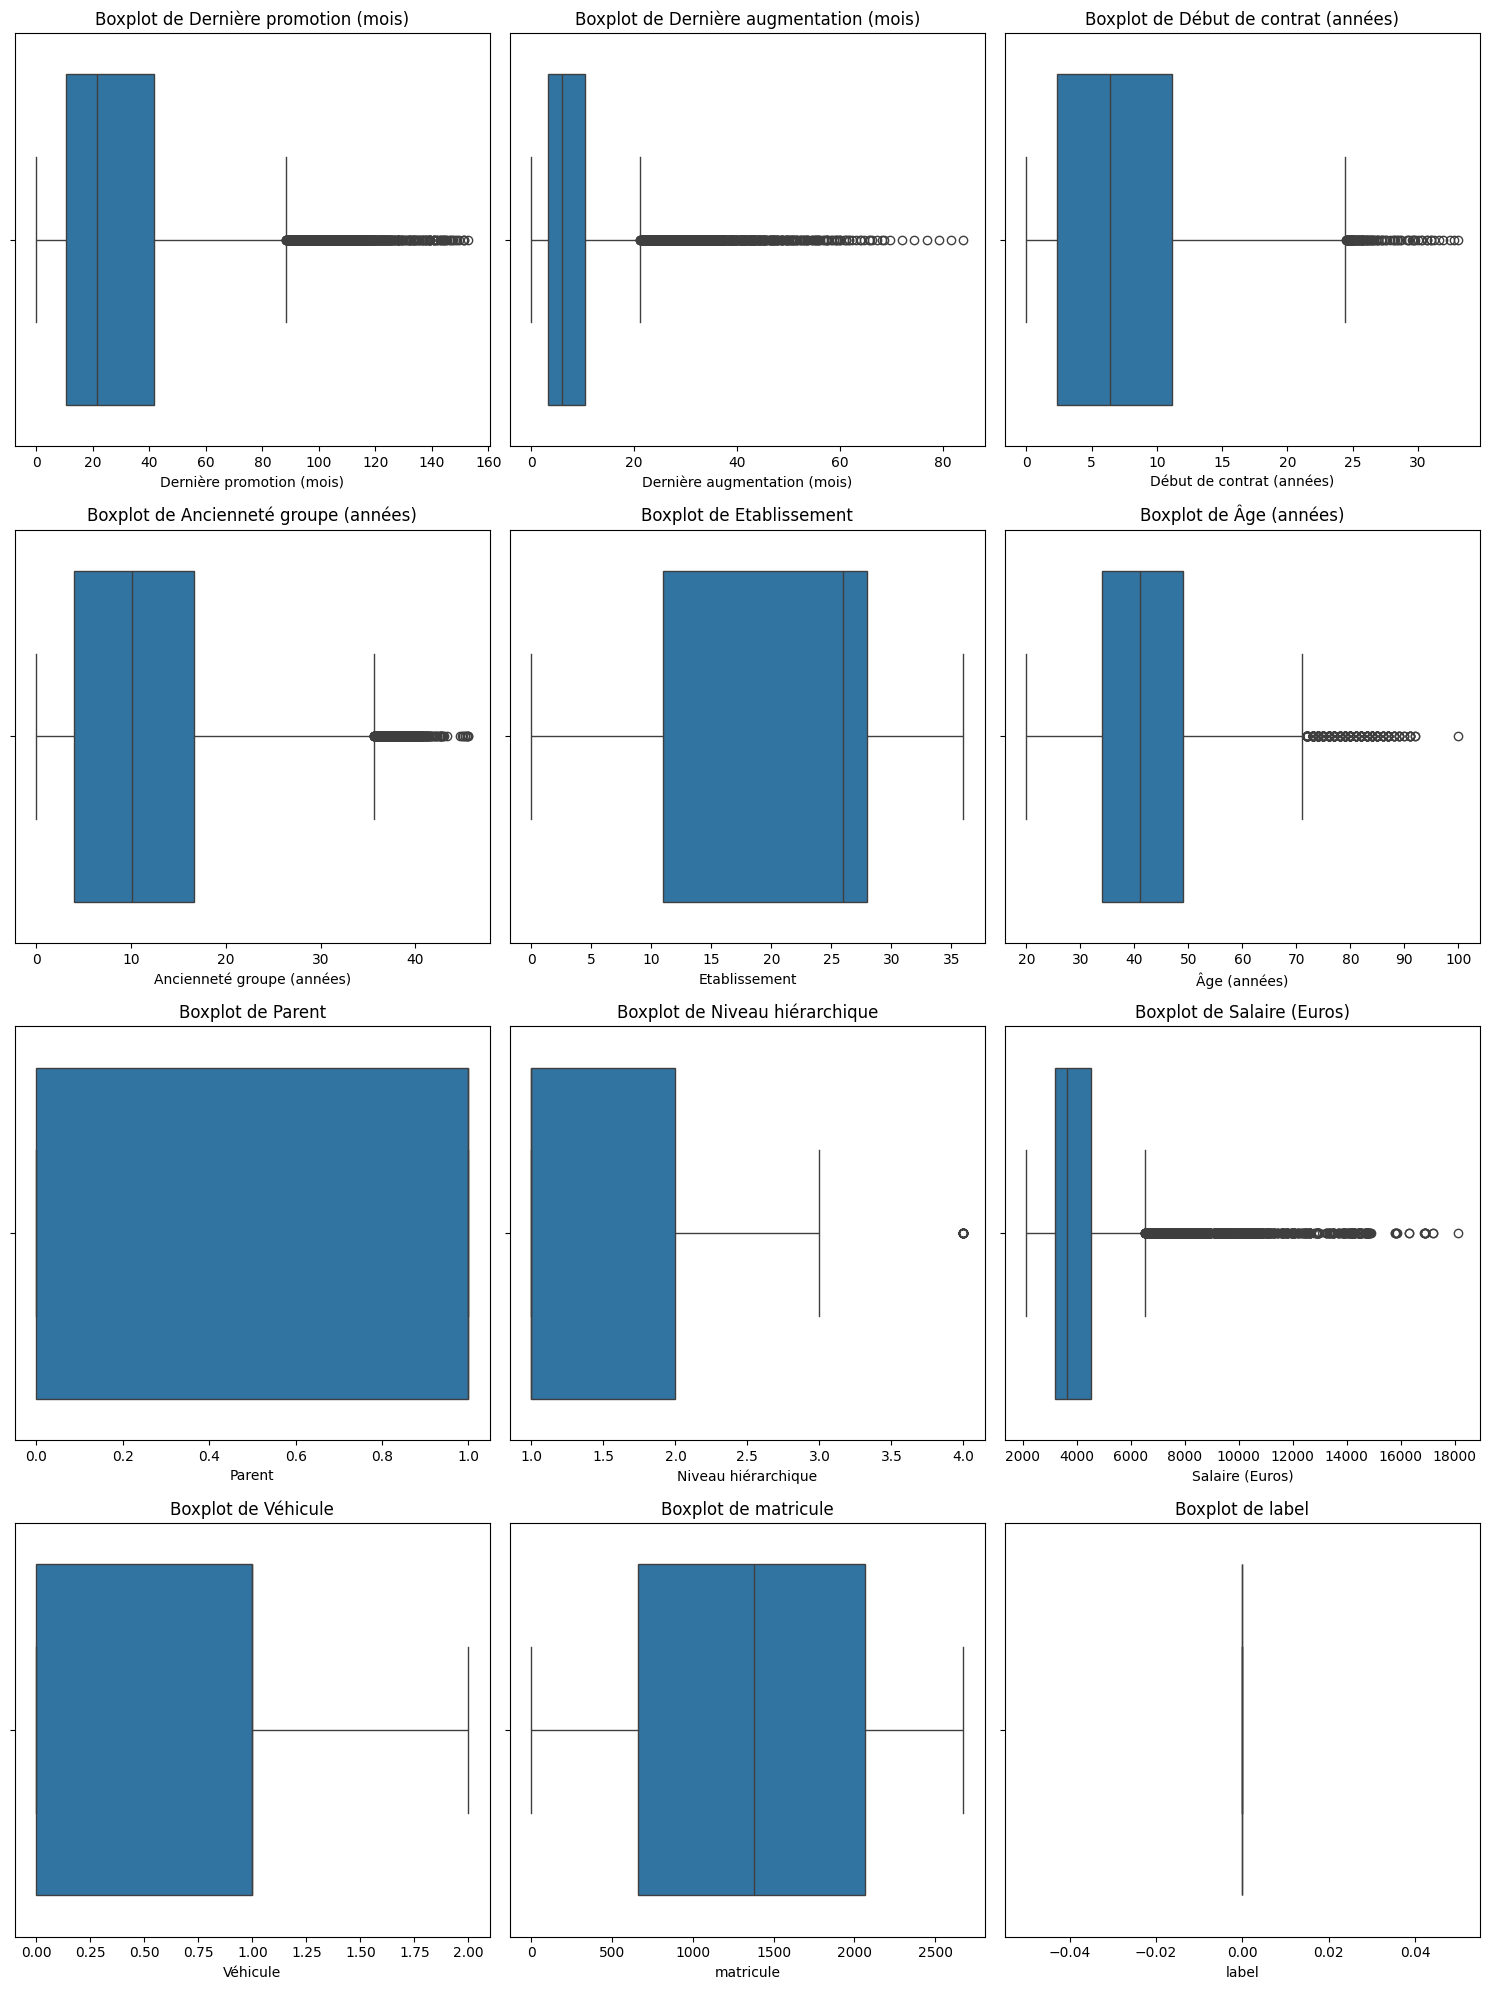

In [13]:
outliers_displaying(df_non_demission)

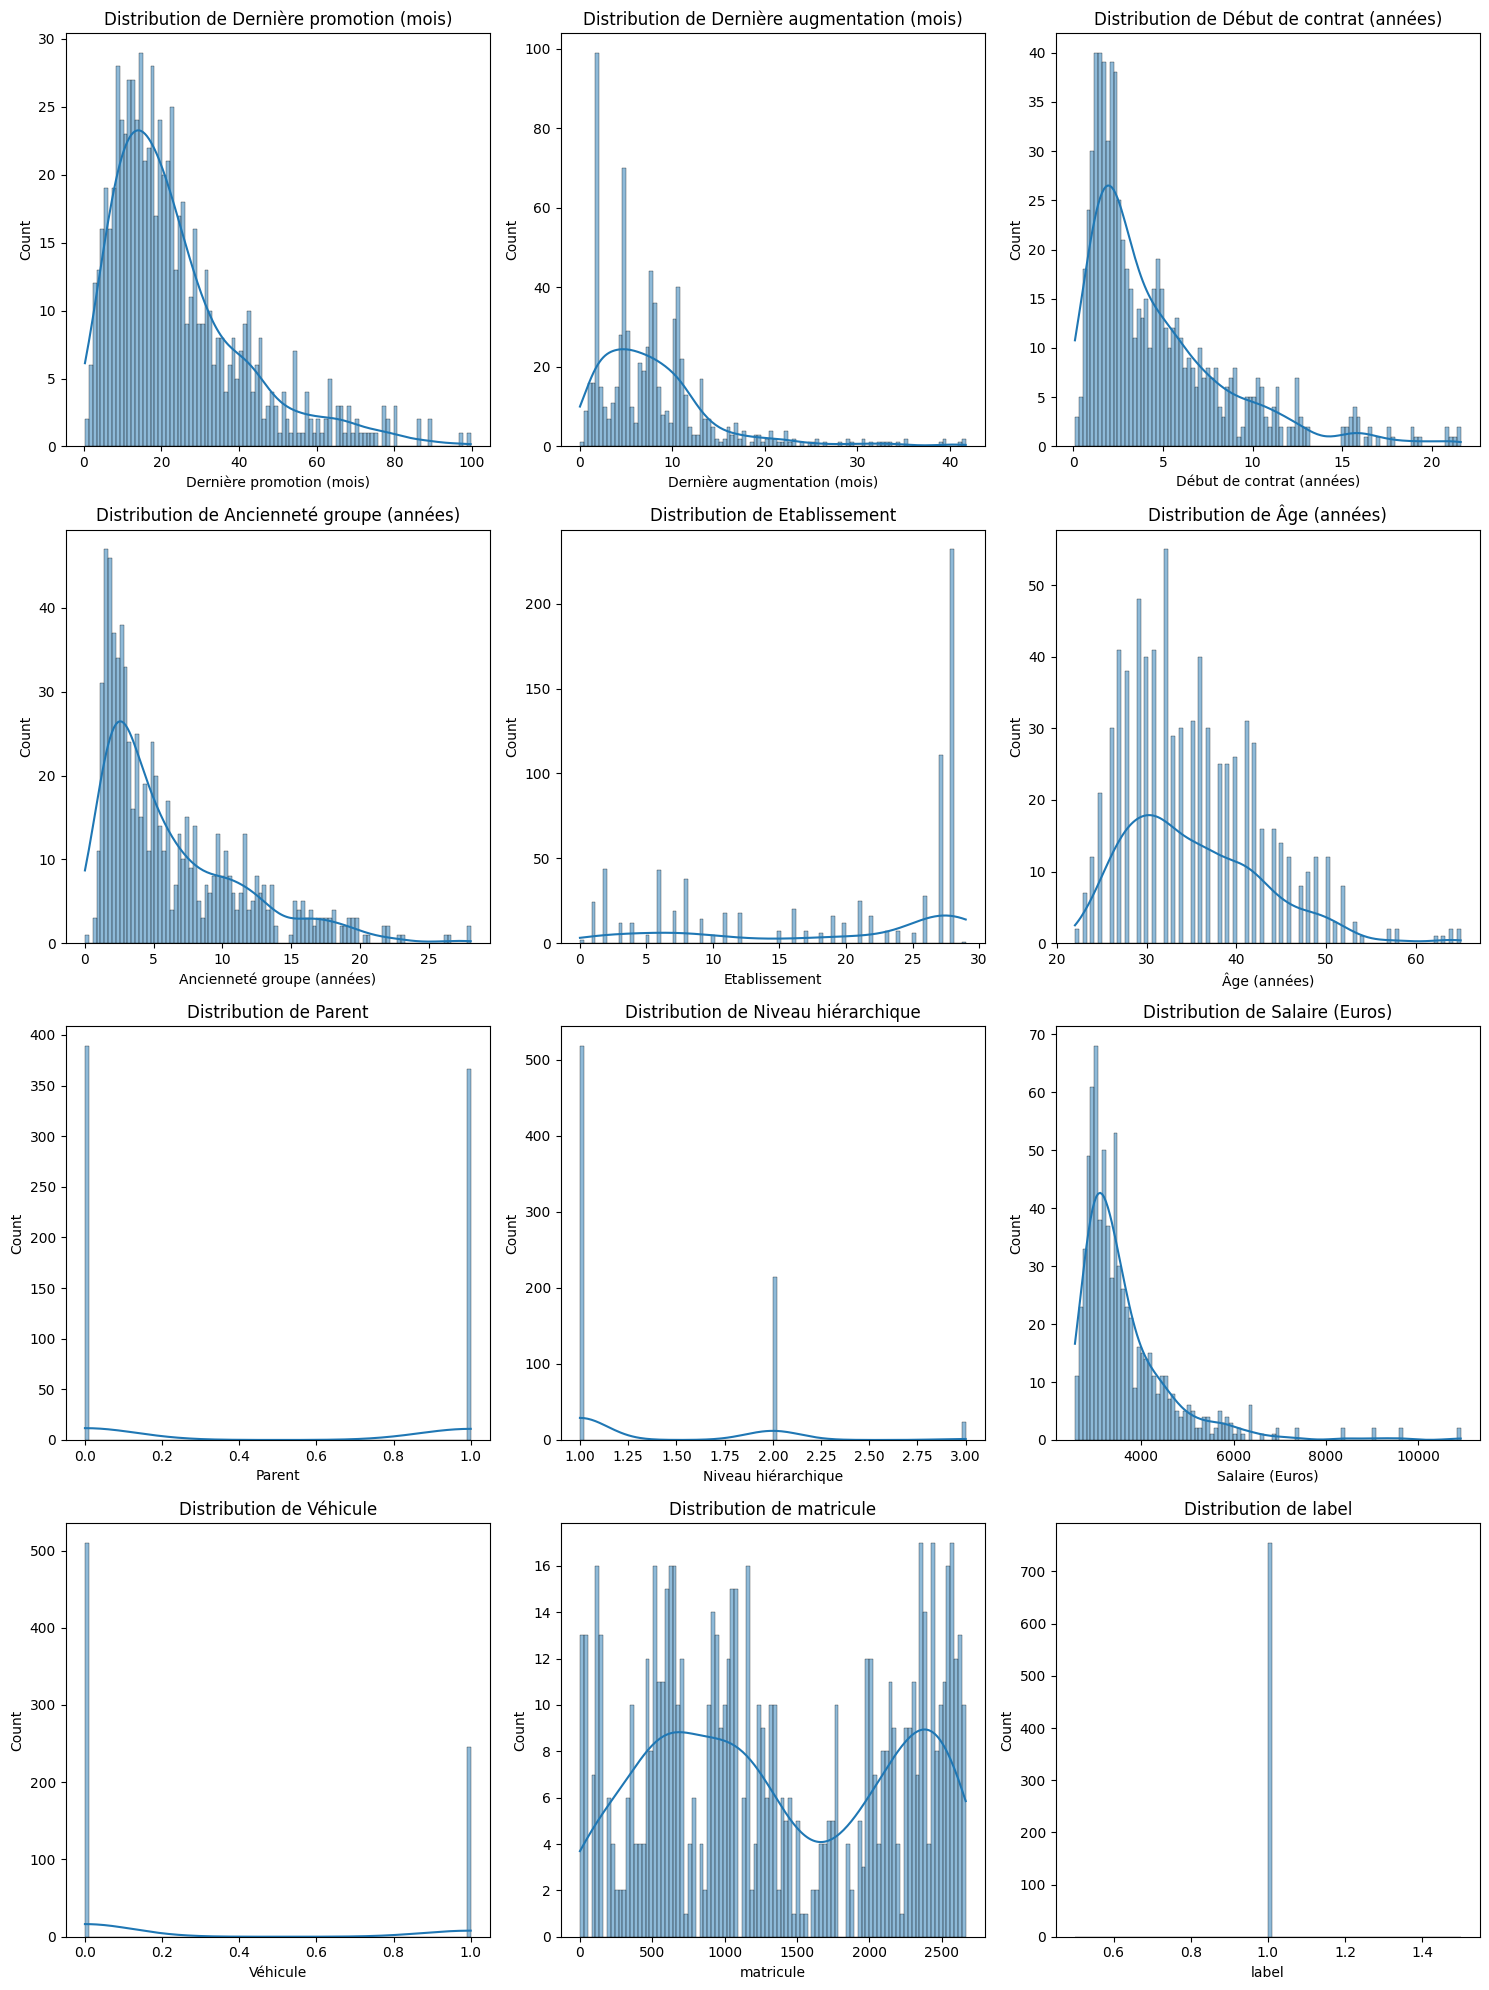

In [14]:
distribution_displaying(df_demission)

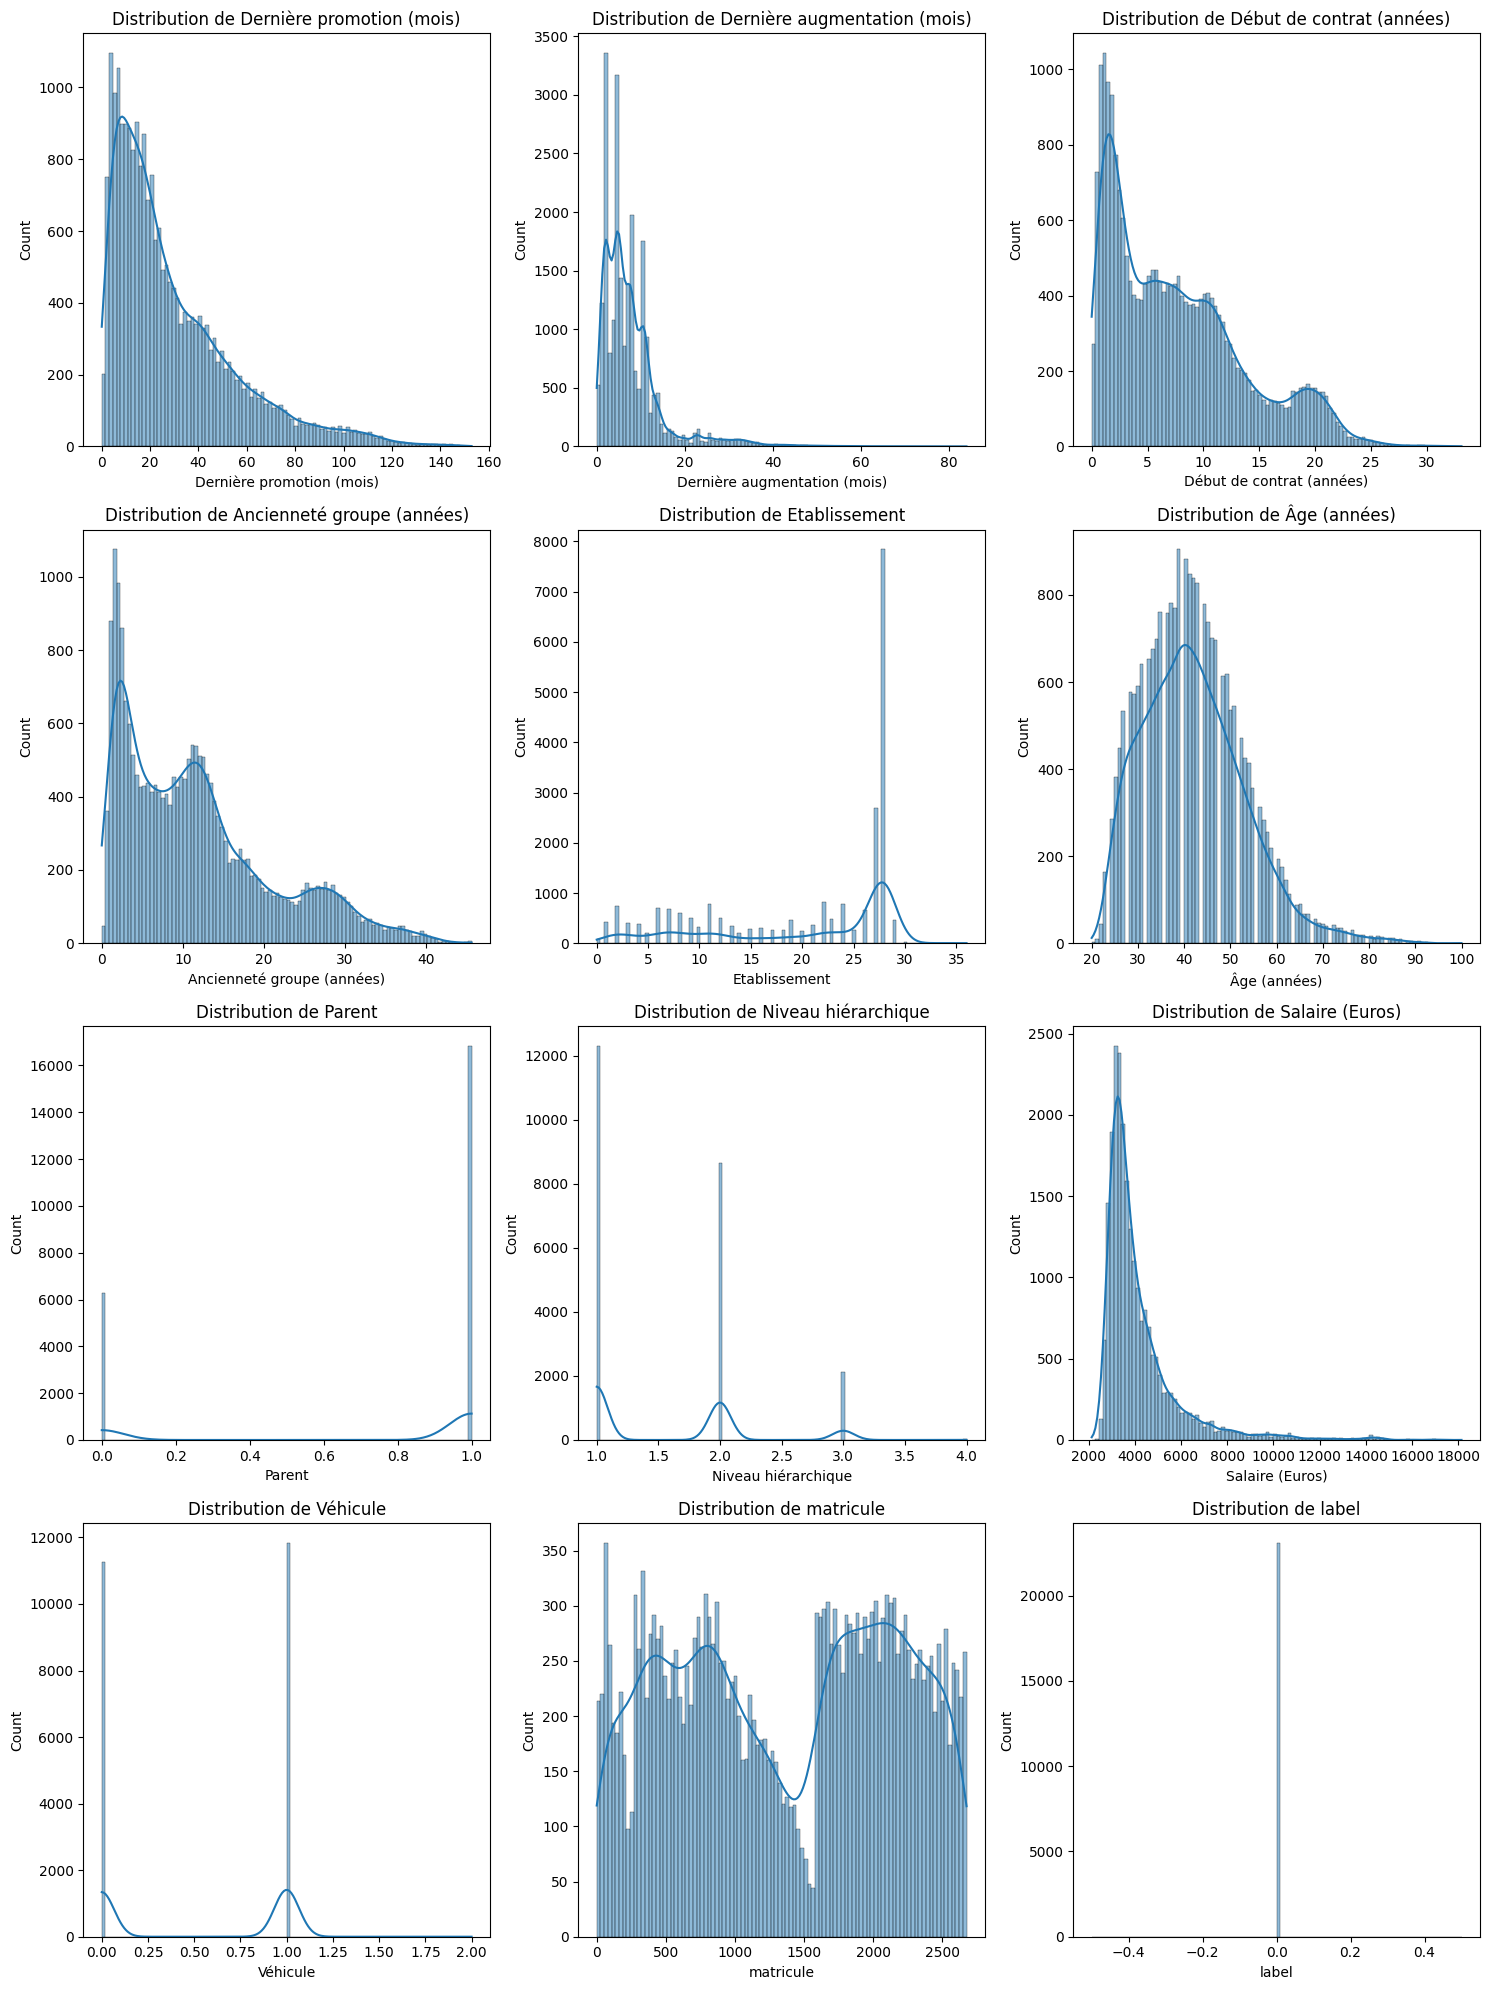

In [15]:
distribution_displaying(df_non_demission)

Exhibition d'un seul parcours

In [16]:
random_employee_demission = df_demission.sample(n=1, random_state=42)
print(random_employee_demission)

        Famille d'emploi  Dernière promotion (mois)  \
9416  Etudes & Technique                  25.559999   

      Dernière augmentation (mois)  Début de contrat (années)  \
9416                          4.54                       3.22   

      Ancienneté groupe (années)  Etablissement  Âge (années)  Parent  \
9416                        3.31             26            29       0   

      Niveau hiérarchique  Salaire (Euros) Statut marital  Véhicule  \
9416                    1             2752    Union libre         0   

      matricule  label  
9416         17      1  


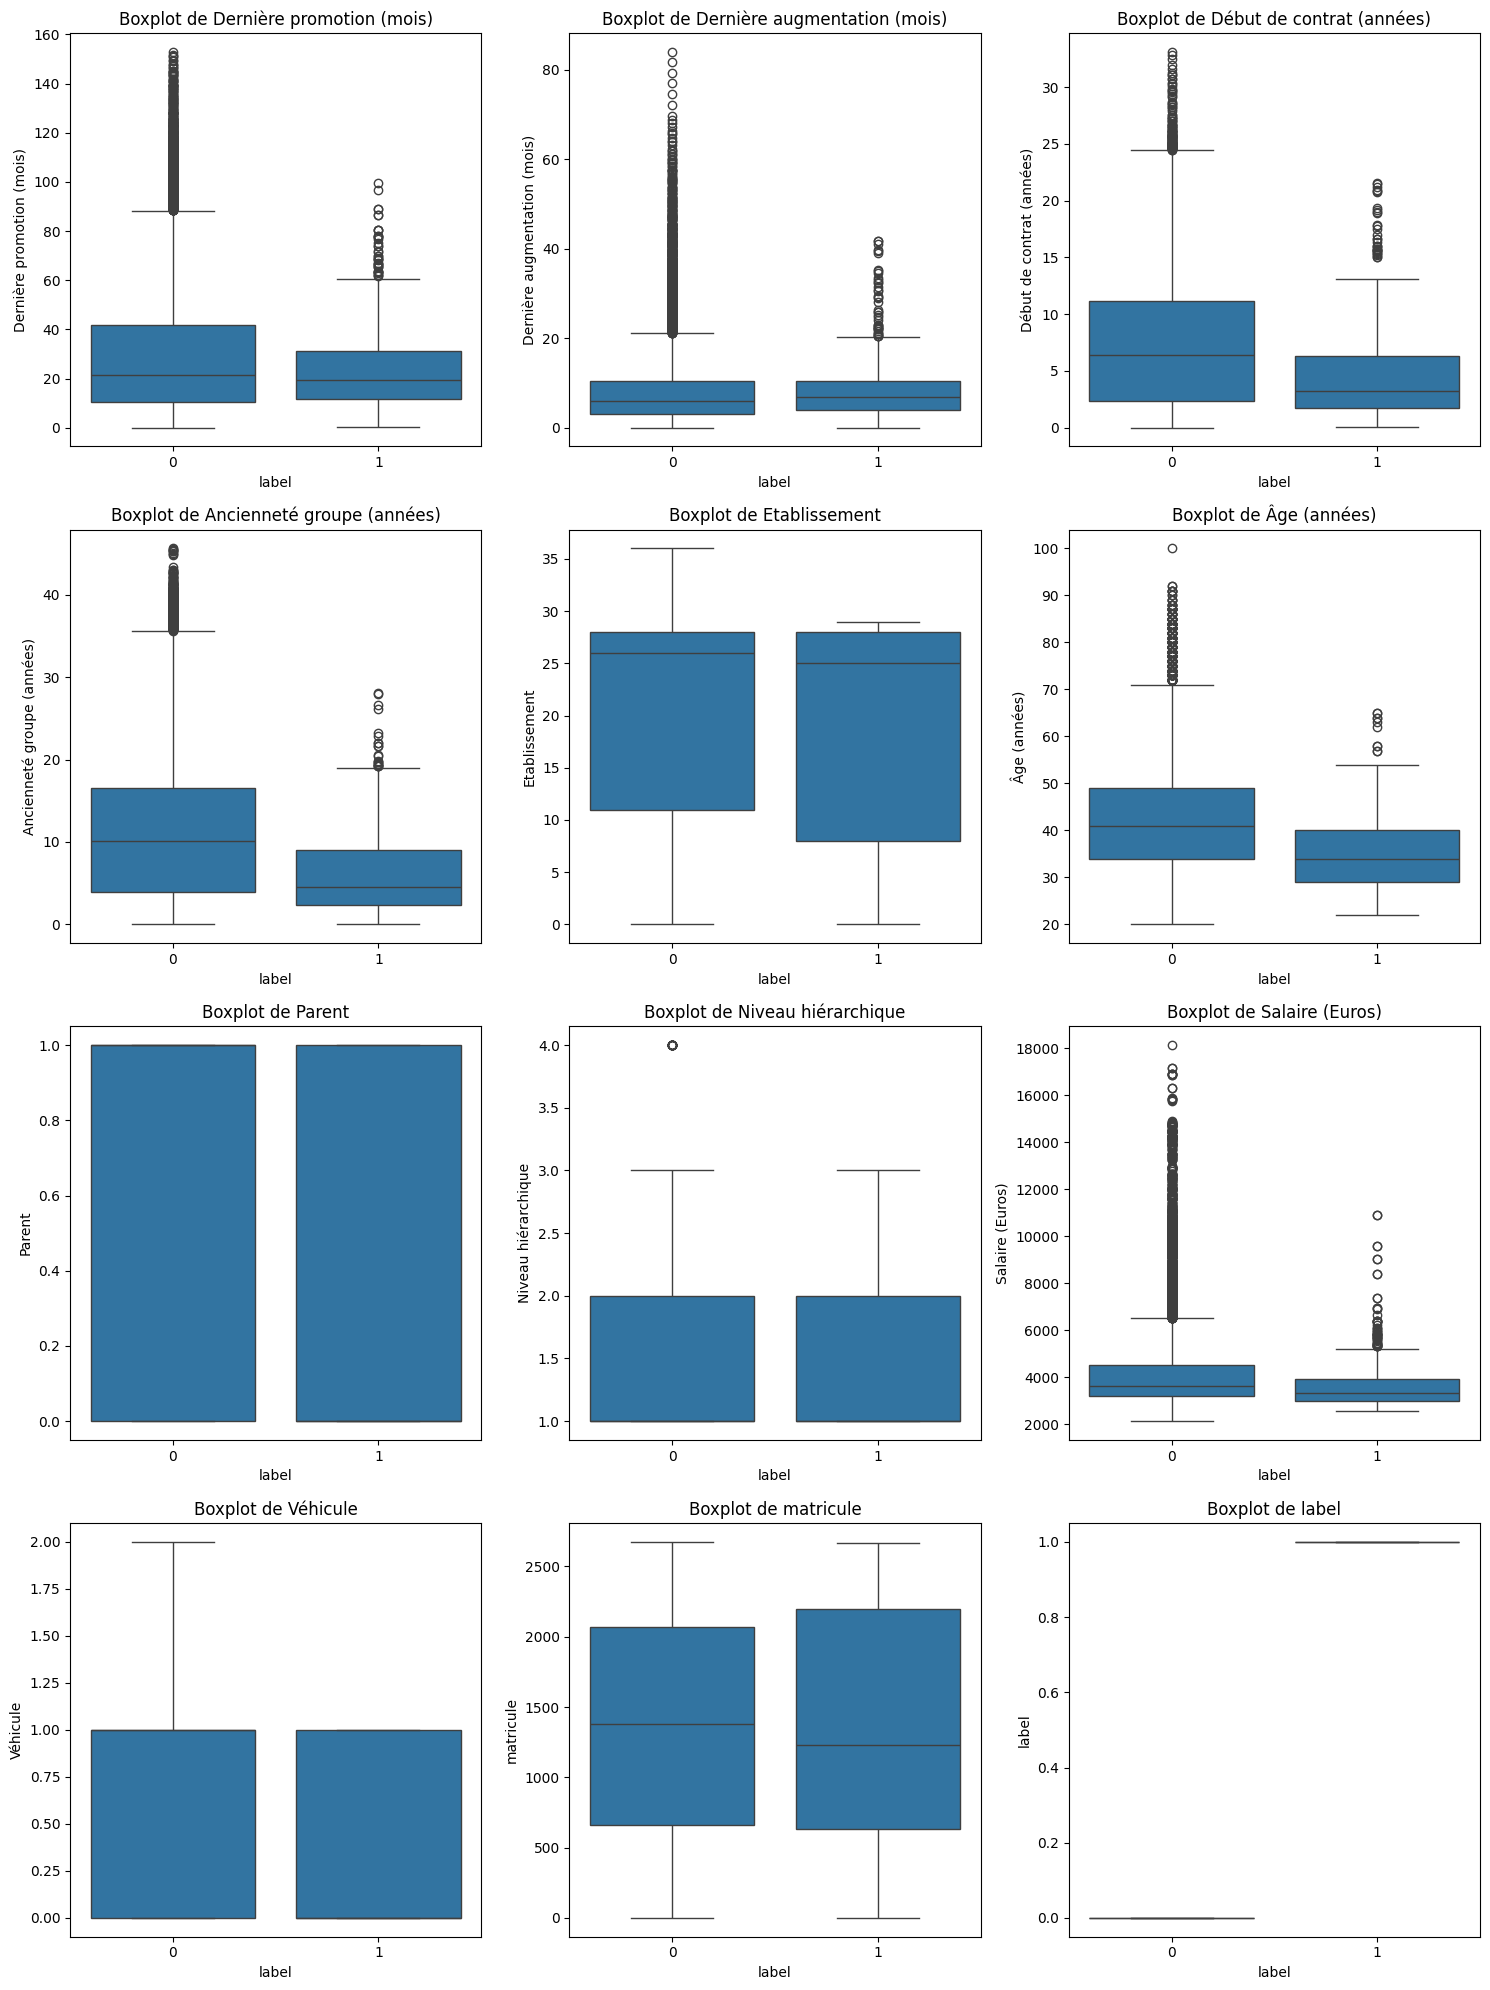

In [21]:
def box_compare_displaying(df):
    num_cols = df.select_dtypes(include=np.number).columns
    num_plots = len(num_cols)
    cols = 3  
    rows = (num_plots + cols - 1) // cols  
    plt.figure(figsize=(15, 5 * rows))  
    
    # i commence à 1
    for i, col in enumerate(num_cols, 1):
        plt.subplot(rows, cols, i)  # Utiliser i au lieu de i + 1
        sb.boxplot(x='label', y=col, data=df)
        plt.title(f"Boxplot de {col}")
        
    plt.tight_layout()  
    plt.show()

box_compare_displaying(df)

## 1. Préparation des données

Nous allons d'abord séparer les variables explicatives (`X`) de la variable cible (`y`, ici `label`) et créer un jeu d'entraînement et un jeu de test. Nous utiliserons le One-Hot Encoding pour gérer les variables catégorielles éventuelles.

In [38]:
%pip install imblearn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Text(0.5, 1.0, 'Class Distribution AFTER SMOTE')

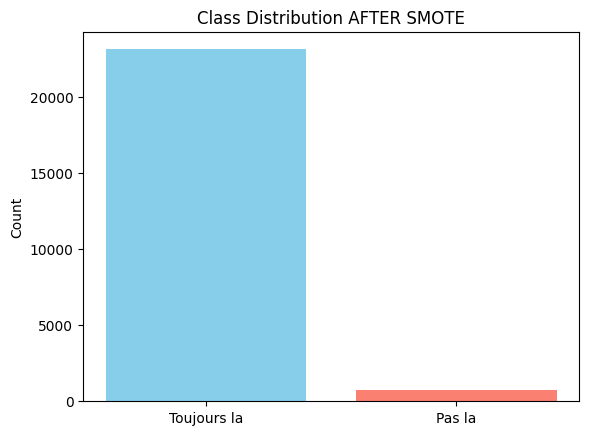

In [39]:
X = df.drop(columns=['label'])
y = df['label']


plt.bar(y.value_counts().index, y.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Toujours la', 'Pas la'])
plt.ylabel("Count")
plt.title("Class Distribution BEFORE SMOTE")

Dimensions de X_train : (36914, 26)
Dimensions de X_test : (4772, 26)


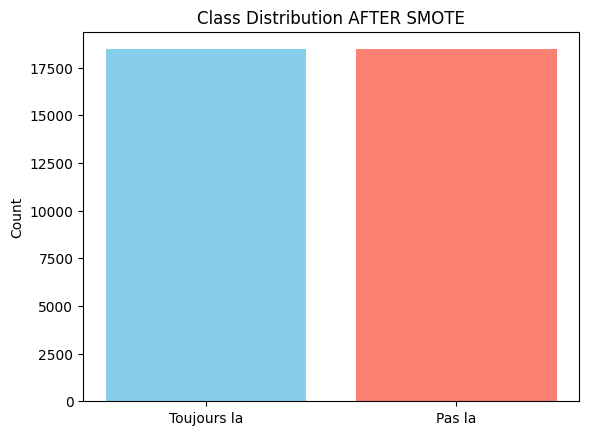

In [40]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

# Encodage des variables catégorielles (si elles existent)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
smote = SMOTE(random_state=1)
X_train, y_train = smote.fit_resample(X_train, y_train)

plt.bar(y_train.value_counts().index, y_train.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Toujours la', 'Pas la'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)

## 2. Modèle à base d'arbres


In [32]:
from sklearn.ensemble import RandomForestClassifier

# Entraînement du modèle
rf_model = RandomForestClassifier(random_state=10, n_estimators=200, max_depth=10, max_leaf_nodes=4)
rf_model.fit(X_train, y_train)

# Évaluation sur le jeu de test
y_pred_rf = rf_model.predict(X_test)

print("--- Modèle à base d'arbres (Random Forest) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Rapport de classification :")
print(classification_report(y_test, y_pred_rf))

--- Modèle à base d'arbres (Random Forest) ---
Accuracy : 0.7615

Rapport de classification :
              precision    recall  f1-score   support

           0       0.98      0.77      0.86      4645
           1       0.05      0.48      0.10       127

    accuracy                           0.76      4772
   macro avg       0.52      0.62      0.48      4772
weighted avg       0.96      0.76      0.84      4772



In [42]:
#pareil avec xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=1, n_estimators=100, max_depth=10, max_leaf_nodes=20)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("--- Modèle à base d'arbres (XGBoost) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}\n")
print("Rapport de classification :")
print(classification_report(y_test, y_pred_xgb))    

/Users/louisvauterin/Desktop/3A/REXIA/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:55:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Modèle à base d'arbres (XGBoost) ---
Accuracy : 0.9719

Rapport de classification :
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4645
           1       0.45      0.27      0.34       127

    accuracy                           0.97      4772
   macro avg       0.72      0.63      0.66      4772
weighted avg       0.97      0.97      0.97      4772



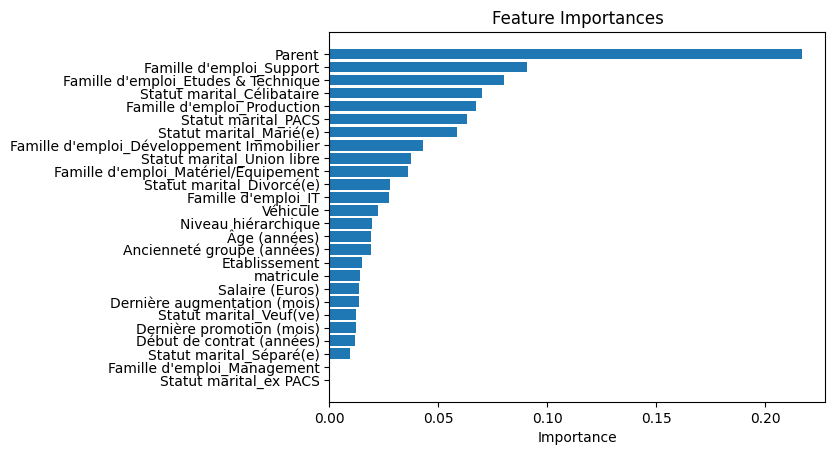

In [47]:
#regarder l'importance des features en utilisant le champ privé feature_importances_
import matplotlib.pyplot as plt
import numpy as np
feature_importances = xgb_model.feature_importances_
features = X.columns
indices = np.argsort(feature_importances)
plt.barh(range(len(indices)), feature_importances[indices], align='center')
plt.yticks(range(len(indices)), features[indices])
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.show()

## 3. Modèle statistique classique

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardisation des données (nécessaire pour la régression logistique et GAM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("--- Modèle statistique (Régression Logistique) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_log):.4f}\n")
print("Rapport de classification :")
print(classification_report(y_test, y_pred_log))

## 4. Modèle linéaire généralisé (GAM)
Les modèles **GAM (Generalized Additive Models)** permettent de modéliser des relations non linéaires via des fonctions de lissage par spline pour toutes les variables continues, tout en gardant chaque terme (et l'effet du modèle) complétement indépendant et explicable visuellement, fonctionnalité cruciale en Explainable AI (XAI). On utilisera `pygam`.

In [ ]:
from pygam import LogisticGAM, s, f

# Configuration classique GAM pour toutes les variables :
# La logistique se configure avec des termes smooth `s(index)` ou `f(index)` par défaut.
# Ici on lui laisse deviner ou on utilise tout X_train en lissage par défaut
gam_model = LogisticGAM(max_iter=100)
# L'entraînement se fait sur les données numpy 
gam_model.fit(X_train, y_train)

y_pred_gam = gam_model.predict(X_test_scaled)

print("--- Modèle GAM (LogisticGAM) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_gam):.4f}\n")
print("Rapport de classification :")
print(classification_report(y_test, y_pred_gam))

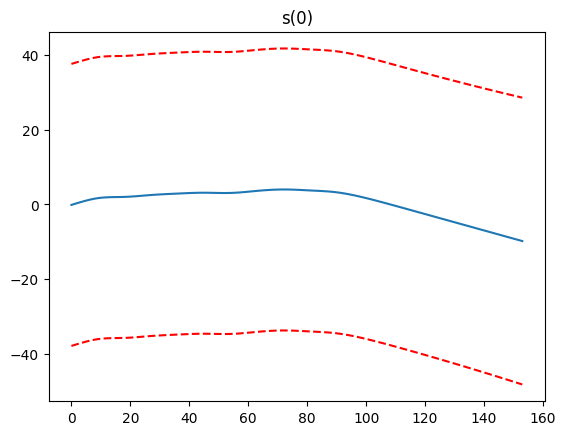

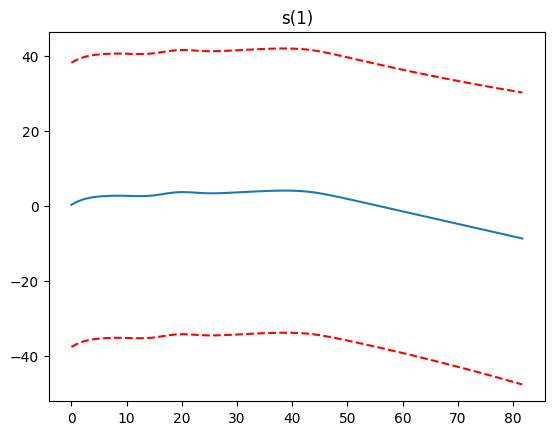

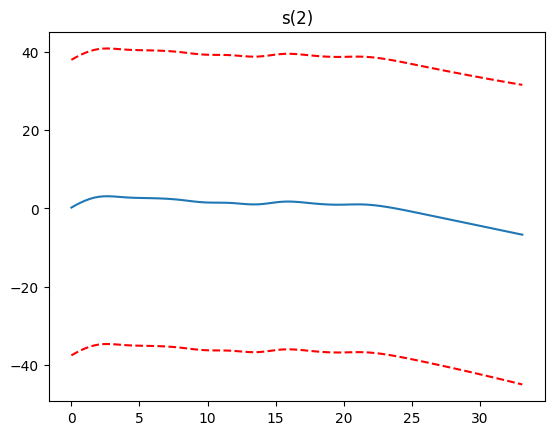

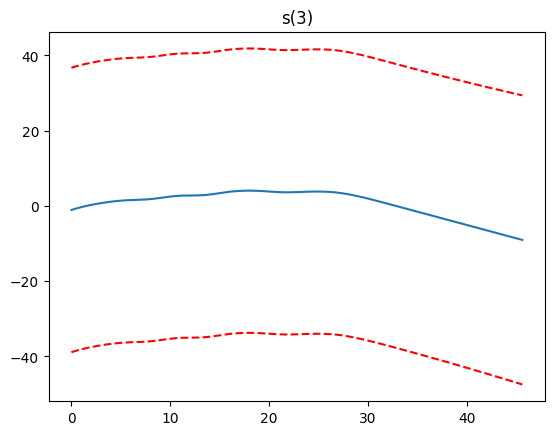

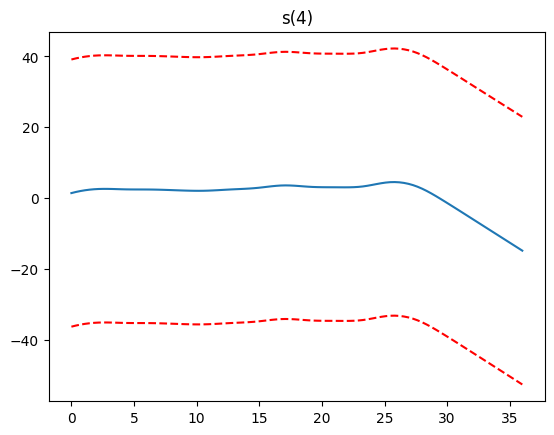

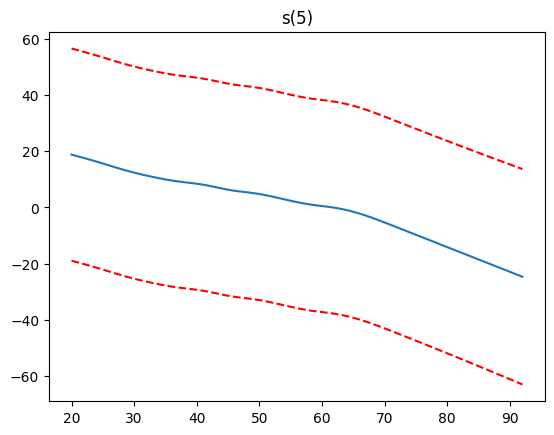

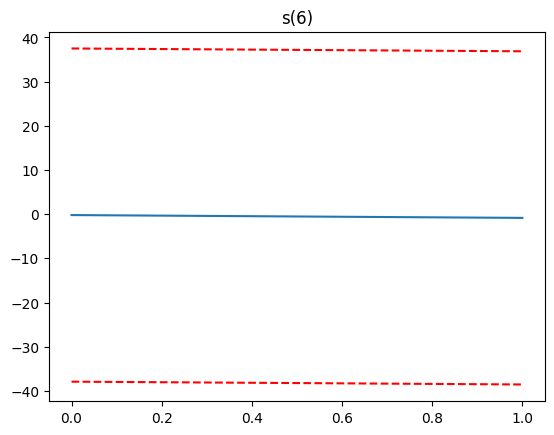

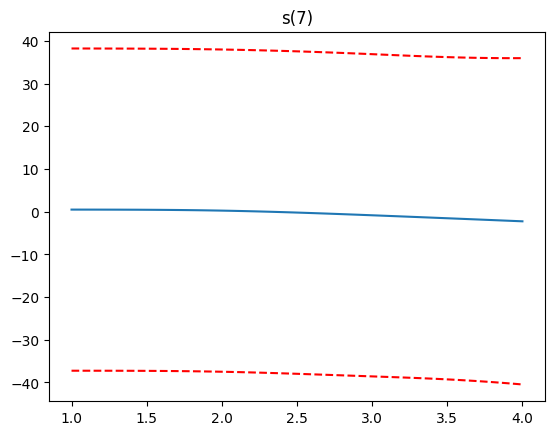

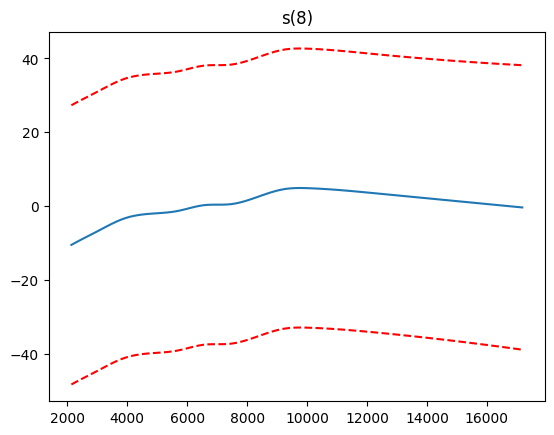

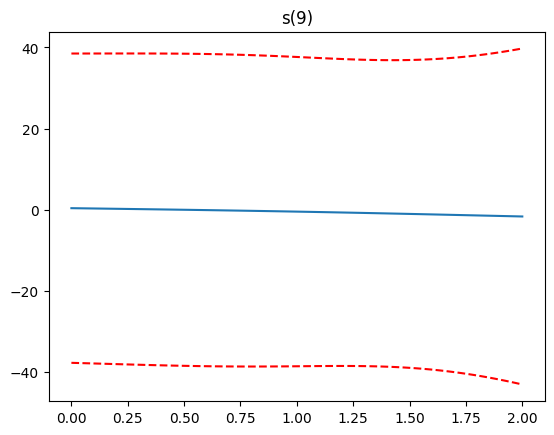

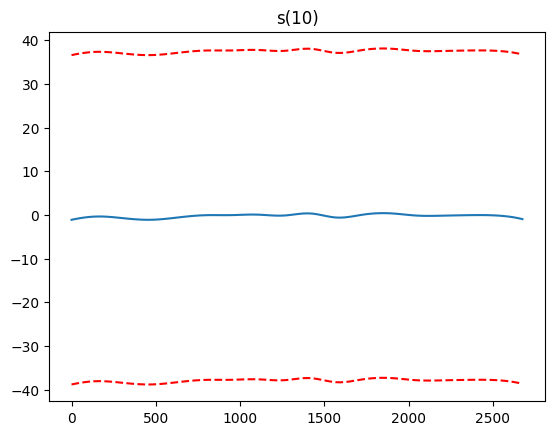

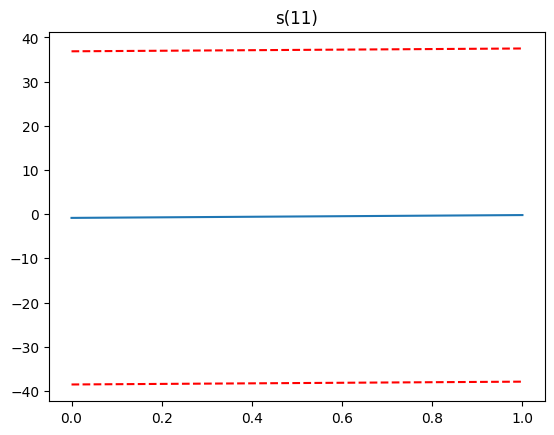

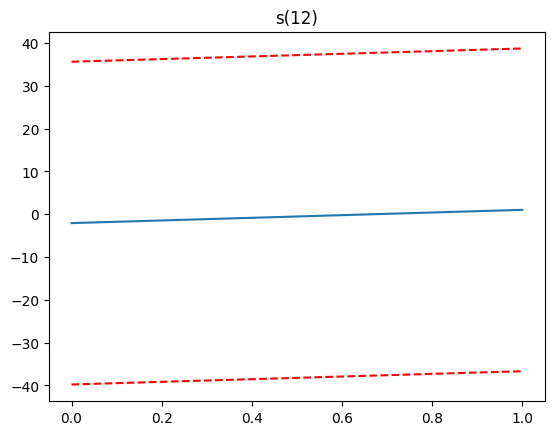

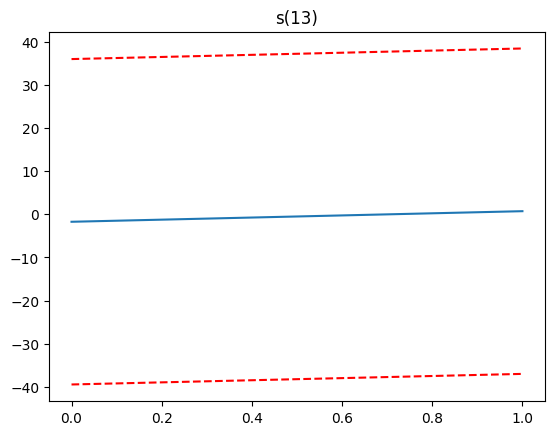

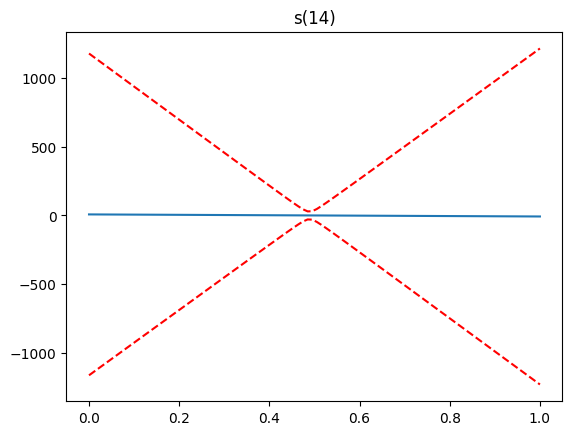

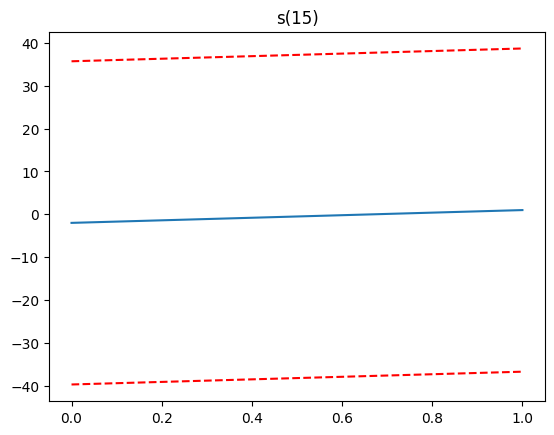

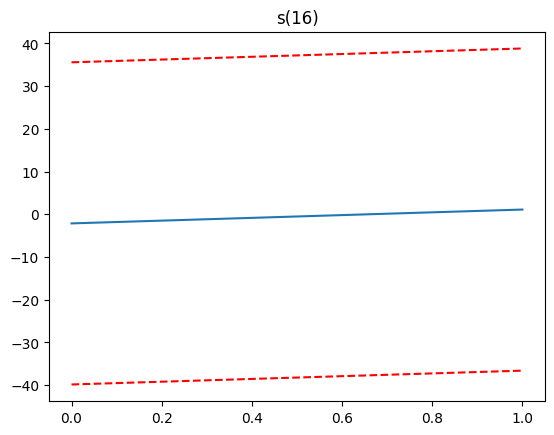

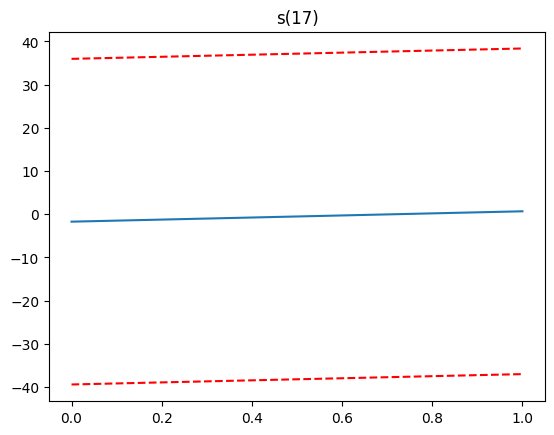

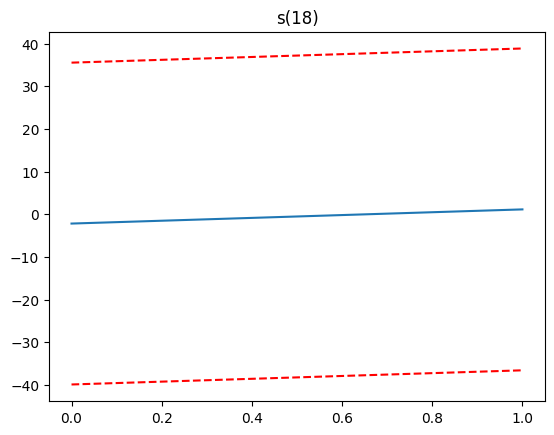

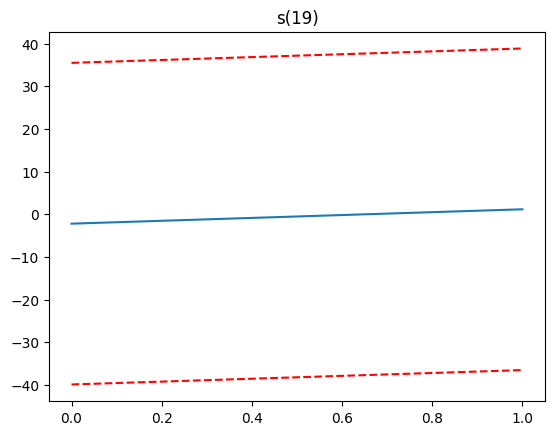

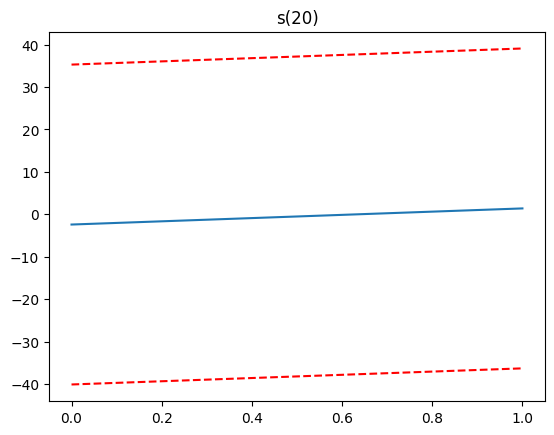

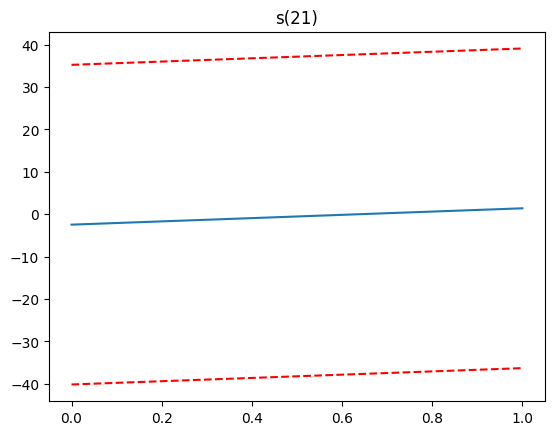

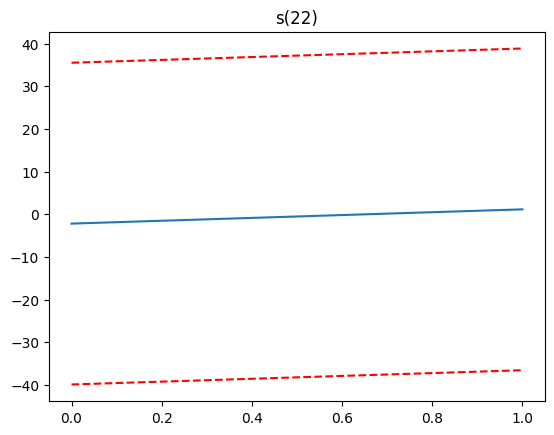

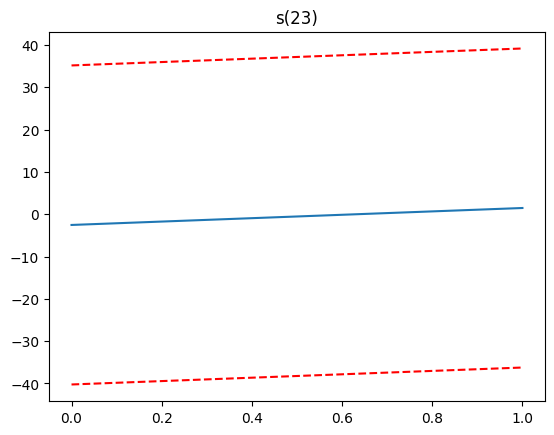

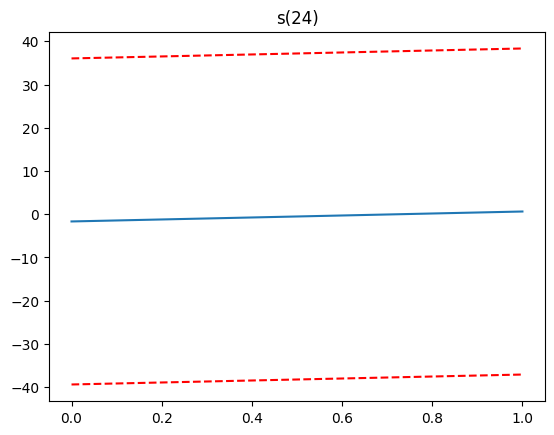

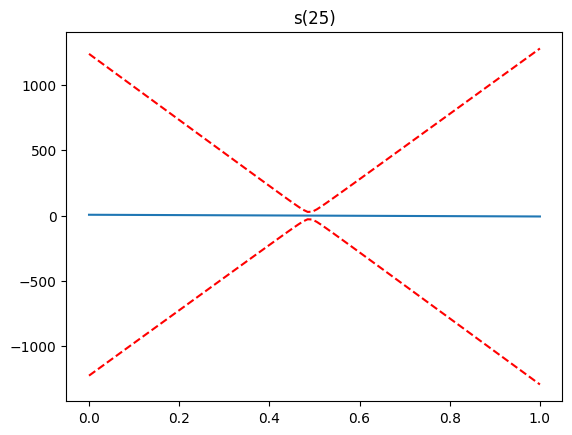

In [46]:
for i, term in enumerate(gam_model.terms):
    if term.isintercept:
        continue

    XX = gam_model.generate_X_grid(term=i)
    pdep, confi = gam_model.partial_dependence(term=i, X=XX, width=0.95)

    plt.figure()
    plt.plot(XX[:, term.feature], pdep)
    plt.plot(XX[:, term.feature], confi, c='r', ls='--')
    plt.title(repr(term))
    plt.show()